# Evaluating FAIRness of biodiversity resources with the FAIR-Checker API

## Aim 
The goal of this notebook is to automate the FAIR assesment of mutliple Biodiversity specific resources DOIs through the [FAIR-Checker tool](https://fair-checker.france-bioinformatique.fr). 
All resulst are stored in a matrix and serialized into a CSV file. Scores can be interpreted as follows: 
 - 0 -> `failure`
 - 1 -> `weak` assesment
 - 2 -> `strong` assesment

To run this notebook you just need the `requests` and `pandas` python libraries. 

The FAIR-Checker API is better described at https://fair-checker.france-bioinformatique.fr/swagger 

Please report any issue at https://github.com/IFB-ElixirFr/fair-checker/issues or contact alban.gaignard@univ-nantes.fr. 

In [1]:
import time
import requests
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

## Input dataset

In [12]:
M61_URLS = [ 
    "https://portal.erga-biodiversity.eu/organism/SAMEA112797446", 
    "https://www.ebi.ac.uk/ena/browser/view/SAMEA112797446", 
    "https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446", 
    "https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446.ldjson",

    "http://portal.boldsystems.org/record/CHOLH011-12", # page not found 
    "https://doi.org/10.5883/DP-Latest", # can manually download JSON data only

    "https://metadatacatalogue.lifewatch.eu/srv/eng/catalog.search#/metadata/dc512697-ed50-40c5-a3cd-1774000444b9", 
    "https://metadatacatalogue.lifewatch.eu/srv/api/records/dc512697-ed50-40c5-a3cd-1774000444b9/formatters/rdf?output=xml", #  non valid RDF/XML 

    "https://doi.org/10.82159/gt66-zt98", # HTTPS + self-signed certificate

    "https://doi.org/10.3535/ZVR-CRA-1Y1?noredirect", # DOI web page not machine-readable, no schema.org 
    "https://doi.org/10.3535/ZVR-CRA-1Y1",  
    "https://disscover.dissco.eu/api/digital-specimen/v1/10.3535/ZVR-CRA-1Y1" # non valid JSON-LD
]
M61_URLS

['https://portal.erga-biodiversity.eu/organism/SAMEA112797446',
 'https://www.ebi.ac.uk/ena/browser/view/SAMEA112797446',
 'https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446',
 'https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446.ldjson',
 'http://portal.boldsystems.org/record/CHOLH011-12',
 'https://doi.org/10.5883/DP-Latest',
 'https://metadatacatalogue.lifewatch.eu/srv/eng/catalog.search#/metadata/dc512697-ed50-40c5-a3cd-1774000444b9',
 'https://metadatacatalogue.lifewatch.eu/srv/api/records/dc512697-ed50-40c5-a3cd-1774000444b9/formatters/rdf?output=xml',
 'https://doi.org/10.82159/gt66-zt98',
 'https://doi.org/10.3535/ZVR-CRA-1Y1?noredirect',
 'https://doi.org/10.3535/ZVR-CRA-1Y1',
 'https://disscover.dissco.eu/api/digital-specimen/v1/10.3535/ZVR-CRA-1Y1']

In [13]:
FC_all_metrics_url = "https://fair-checker.france-bioinformatique.fr/api/check/legacy/metrics_all"

## FAIR assesment over all inputs 

In [14]:
from json import JSONDecodeError
import pandas as pd
import time
import requests
import json
from tqdm.notebook import tqdm

df = pd.DataFrame()
rows = []

for u in tqdm(M61_URLS):
#for u in tqdm(URLs):
    print("Evaluating "+u)
    start = time.time()
    res = requests.get(url=FC_all_metrics_url, params={"url": u})
    eval_in_sec = time.time() - start
    
    try: 
        evaluations = res.json()
        row = {"URL": u}
    
        # iterating over all evaluation results
        for e in evaluations:
            #print(e)
            row[e["metric"]] = int(e["score"])
        # row["duration (s)"] = round(eval_in_sec, 2)
        # print(row)
        rows.append(row)
    except JSONDecodeError as error:
        print("Cannot get FAIR assesment for "+u)
        print(res.text)
        

  0%|          | 0/12 [00:00<?, ?it/s]

Evaluating https://portal.erga-biodiversity.eu/organism/SAMEA112797446
Evaluating https://www.ebi.ac.uk/ena/browser/view/SAMEA112797446
Evaluating https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446
Evaluating https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446.ldjson
Evaluating http://portal.boldsystems.org/record/CHOLH011-12
Evaluating https://doi.org/10.5883/DP-Latest
Evaluating https://metadatacatalogue.lifewatch.eu/srv/eng/catalog.search#/metadata/dc512697-ed50-40c5-a3cd-1774000444b9
Evaluating https://metadatacatalogue.lifewatch.eu/srv/api/records/dc512697-ed50-40c5-a3cd-1774000444b9/formatters/rdf?output=xml
Evaluating https://doi.org/10.82159/gt66-zt98
Evaluating https://doi.org/10.3535/ZVR-CRA-1Y1?noredirect
Evaluating https://doi.org/10.3535/ZVR-CRA-1Y1
Evaluating https://disscover.dissco.eu/api/digital-specimen/v1/10.3535/ZVR-CRA-1Y1


## Evaluation matrix

In [15]:
from IPython.display import display, Markdown
df = pd.DataFrame.from_records(rows)

df["F_score"] = df.apply(
    lambda row: round((row["F1A"] + row["F1B"] + row["F2A"] + row["F2B"]) * 100 / 8, 1),
    axis=1,
)
df["A_score"] = df.apply(
    lambda row: round((row["A1.1"] + row["A1.2"]) * 100 / 4, 1), axis=1
)
df["I_score"] = df.apply(
    lambda row: round((row["I1"] + row["I2"] + row["I3"]) * 100 / 6, 1), axis=1
)
df["R_score"] = df.apply(
    lambda row: round((row["R1.1"] + row["R1.2"] + row["R1.3"]) * 100 / 6, 1), axis=1
)
# df['FAIR_score'] = df.apply(lambda row: round((row["F_score"] + row["A_score"] + row["I_score"] + row["R_score"])/4, 1), axis = 1)
df["FAIR_score"] = df.apply(
    lambda row: round(
        (
            row["F1A"]
            + row["F1B"]
            + row["F2A"]
            + row["F2B"]
            + row["A1.1"]
            + row["A1.2"]
            + row["I1"]
            + row["I2"]
            + row["I3"]
            + row["R1.1"]
            + row["R1.2"]
            + row["R1.3"]
        )
        * 100
        / 24,
        1,
    ),
    axis=1,
)

df.to_csv("M62-biodiv-fc_evals-2026.csv")

md = df.to_markdown()
display(Markdown(md))

|    | URL                                                                                                                   |   F1A |   F1B |   F2A |   F2B |   A1.1 |   A1.2 |   I1 |   I2 |   I3 |   R1.1 |   R1.2 |   R1.3 |   F_score |   A_score |   I_score |   R_score |   FAIR_score |
|---:|:----------------------------------------------------------------------------------------------------------------------|------:|------:|------:|------:|-------:|-------:|-----:|-----:|-----:|-------:|-------:|-------:|----------:|----------:|----------:|----------:|-------------:|
|  0 | https://portal.erga-biodiversity.eu/organism/SAMEA112797446                                                           |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |        25 |        50 |       0   |       0   |         16.7 |
|  1 | https://www.ebi.ac.uk/ena/browser/view/SAMEA112797446                                                                 |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |        25 |        50 |       0   |       0   |         16.7 |
|  2 | https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446                                                               |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |        25 |        50 |       0   |       0   |         16.7 |
|  3 | https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446.ldjson                                                        |     2 |     2 |     1 |     1 |      2 |      0 |    1 |    1 |    0 |      0 |      0 |      1 |        75 |        50 |      33.3 |      16.7 |         45.8 |
|  4 | http://portal.boldsystems.org/record/CHOLH011-12                                                                      |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |        25 |        50 |       0   |       0   |         16.7 |
|  5 | https://doi.org/10.5883/DP-Latest                                                                                     |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |        25 |        50 |       0   |       0   |         16.7 |
|  6 | https://metadatacatalogue.lifewatch.eu/srv/eng/catalog.search#/metadata/dc512697-ed50-40c5-a3cd-1774000444b9          |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |        25 |        50 |       0   |       0   |         16.7 |
|  7 | https://metadatacatalogue.lifewatch.eu/srv/api/records/dc512697-ed50-40c5-a3cd-1774000444b9/formatters/rdf?output=xml |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |        25 |        50 |       0   |       0   |         16.7 |
|  8 | https://doi.org/10.82159/gt66-zt98                                                                                    |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |        25 |        50 |       0   |       0   |         16.7 |
|  9 | https://doi.org/10.3535/ZVR-CRA-1Y1?noredirect                                                                        |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |        25 |        50 |       0   |       0   |         16.7 |
| 10 | https://doi.org/10.3535/ZVR-CRA-1Y1                                                                                   |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |        25 |        50 |       0   |       0   |         16.7 |
| 11 | https://disscover.dissco.eu/api/digital-specimen/v1/10.3535/ZVR-CRA-1Y1                                               |     2 |     0 |     0 |     0 |      2 |      0 |    0 |    0 |    0 |      0 |      0 |      0 |        25 |        50 |       0   |       0   |         16.7 |

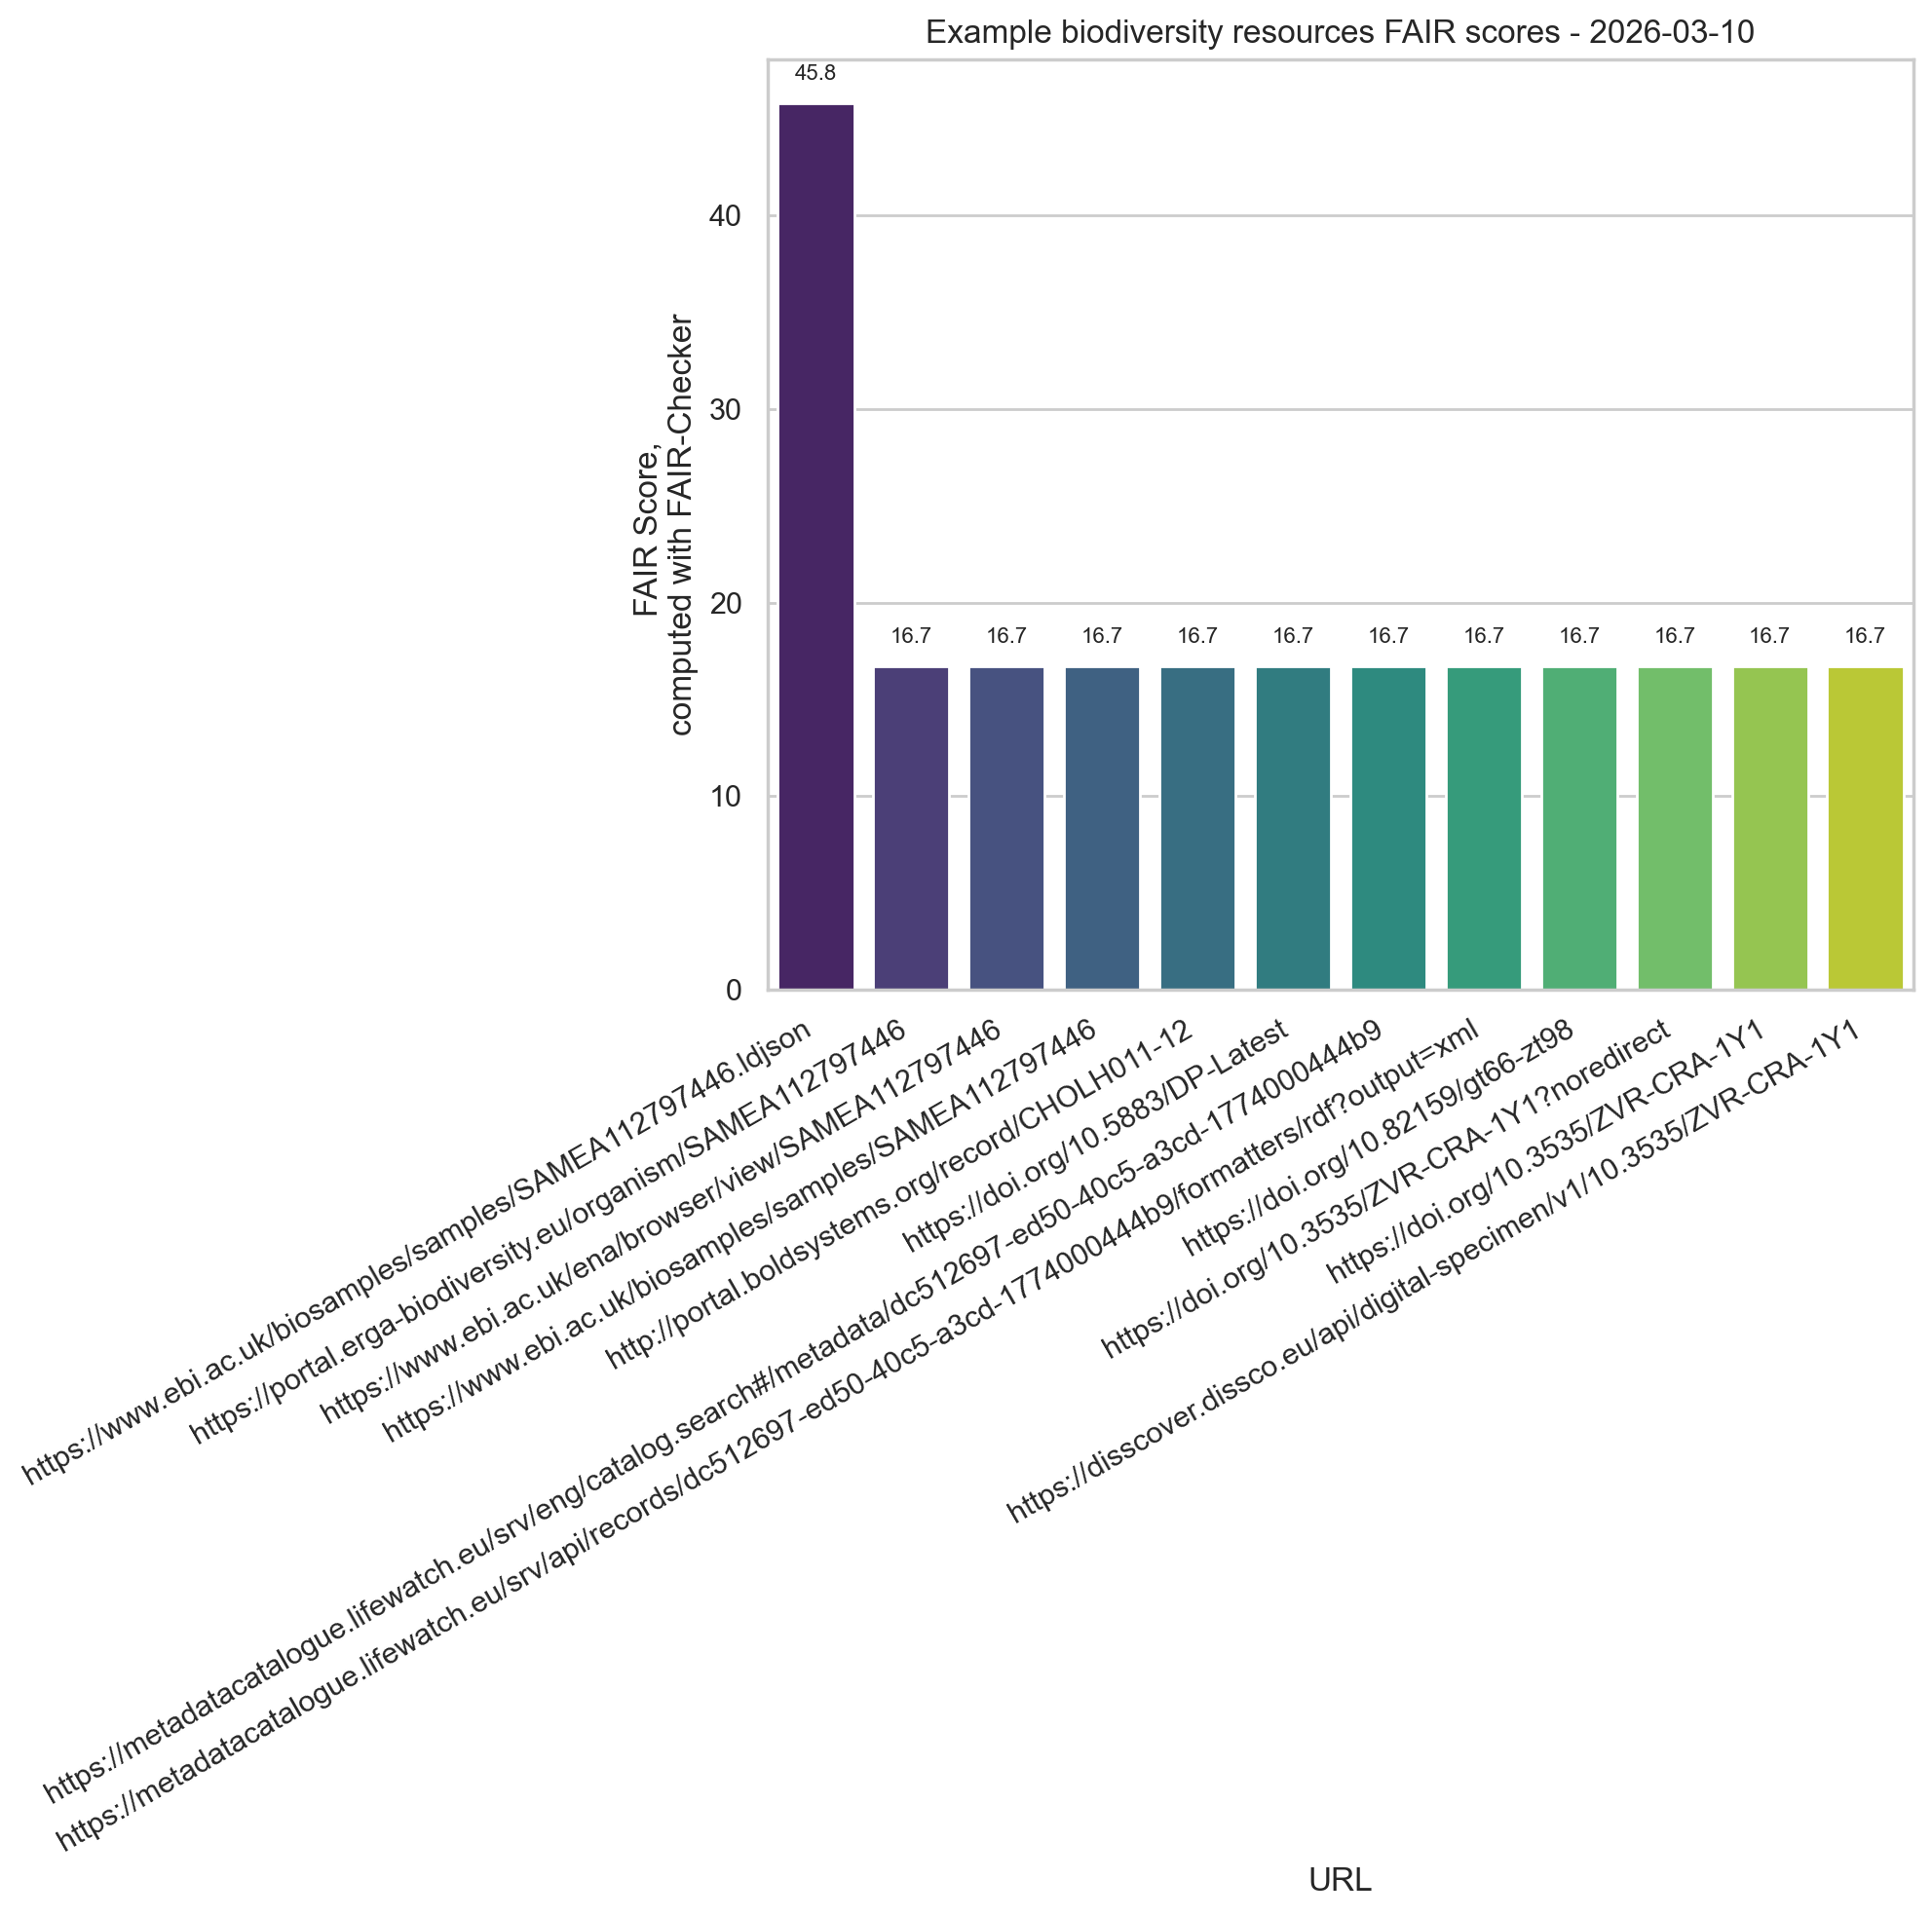

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns 


df = pd.read_csv("M62-biodiv-fc_evals-2026.csv", index_col=0)

today = time.strftime("%Y-%m-%d")

# plot with seaborn a bar plot for all FAIR scores of the DOIs
plt.figure(figsize=(10, 10))
plt.rcParams["figure.dpi"] = 200
plt.rcParams["font.size"] = 8

# sort the dataframe by FAIR score
df = df.sort_values(by="FAIR_score", ascending=False, ignore_index=True)

sns.set_theme(style="whitegrid")
sns.barplot(data=df, x="URL", y="FAIR_score", hue="URL", palette="viridis", legend=False)

# annotate the bars with the FAIR score
for index, row in df.iterrows():
    plt.text(
        index,
        row["FAIR_score"] + 1,
        str(row["FAIR_score"]),
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.xticks(rotation=30, ha="right")
plt.title(f"Example biodiversity resources FAIR scores \n {today}")
plt.xlabel("URL")
plt.ylabel("FAIR Score (from FAIR-Checker)")
plt.tight_layout()


plt.savefig("M62-biodiv_fair_scores.png", dpi=300)
plt.savefig("M62-biodiv_fair_scores.pdf", dpi=300)
plt.show()